In [2]:
%reload_ext autoreload
%autoreload 2

from variables import filenames, features, target
from load_dataset import load
from pre_processing import apply, ReplaceInfWithNan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = load(filenames)
df = apply(df)
df.head()

Quantidade de duplicatas antes de remover:  308381


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [4]:
df = df[df['Label'].isin(['BENIGN','DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye'])]
df['Label'].value_counts()

Label
BENIGN              2096484
DoS Hulk             172849
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
# máscara de NaN
mask_null = df.isnull()

# máscara de Inf apenas em colunas numéricas
num_cols = df.select_dtypes(include=[np.number]).columns
mask_inf = pd.DataFrame(False, index=df.index, columns=df.columns)
mask_inf[num_cols] = np.isinf(df[num_cols])

# máscara combinada: NaN OU Inf
mask_invalid = mask_null | mask_inf

# total por label
label_counts = df.groupby(target).size().rename('label_total')

# contagem de inválidos por label
invalid_counts = mask_invalid.groupby(df[target]).sum()

# formato longo
result = (
    invalid_counts
    .stack()
    .reset_index()
    .rename(columns={
        'level_1': 'column',
        0: 'invalid_count'
    })
)

# adiciona total da label
result = result.merge(
    label_counts.reset_index(),
    on=target
)

# percentual
result['invalid_pct'] = (
    result['invalid_count'] / result['label_total']
) * 100

# mantém apenas colunas com problema
result = result[result['invalid_count'] > 0]

# organiza
result = result[
    ['column', target, 'label_total', 'invalid_count', 'invalid_pct']
].sort_values(['column', target])

result

,column,Label,label_total,invalid_count,invalid_pct
14,Flow Bytes/s,BENIGN,2096484,1427,0.068066
172,Flow Bytes/s,DoS Hulk,172849,3,0.001736
15,Flow Packets/s,BENIGN,2096484,1427,0.068066
173,Flow Packets/s,DoS Hulk,172849,3,0.001736


In [7]:
# Remove valores nulos e infinitos da base
df.replace([np.inf, -np.inf], np.nan, inplace=True)

linhas_antes = len(df)
valores_nulos_antes = int(df.isna().sum().sum())

df.dropna(inplace=True)

print(f"Linhas antes: {linhas_antes}")
print(f"Valores nulos/inf convertidos para NaN: {valores_nulos_antes}")
print(f"Linhas após limpeza: {len(df)}")
print(f"Total de NaN restantes: {int(df.isna().sum().sum())}")

Linhas antes: 2290232
Valores nulos/inf convertidos para NaN: 2860
Linhas após limpeza: 2288802
Total de NaN restantes: 0


In [10]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Label'])

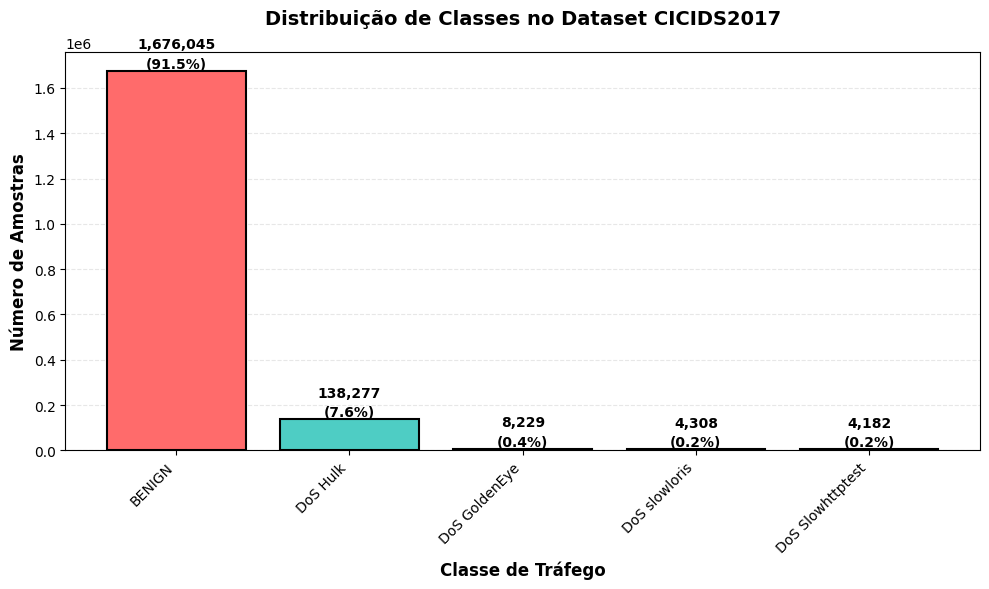

In [11]:
# Criar gráfico de balanceamento de classes
fig, ax = plt.subplots(figsize=(10, 6))

# Dados de contagem por label
label_data = df_train[target].value_counts().sort_values(ascending=False)

# Cores personalizadas
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Gráfico de barras
bars = ax.bar(range(len(label_data)), label_data.values, color=colors, edgecolor='black', linewidth=1.5)

# Personalizações
ax.set_xlabel('Classe de Tráfego', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Amostras', fontsize=12, fontweight='bold')
ax.set_title('Distribuição de Classes no Dataset CICIDS2017', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(range(len(label_data)))
ax.set_xticklabels(label_data.index, rotation=45, ha='right')

# Adicionar valores nas barras (COM linespacing)
for bar, value in zip(bars, label_data.values):
    height = bar.get_height()
    percentage = (value / label_data.sum()) * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height,
        f'{value:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        linespacing=1.5
    )

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Ajustar layout
plt.tight_layout()
plt.savefig('imagens/class_distribution.png', dpi=300)
plt.show()

In [14]:
from imblearn.under_sampling import RandomUnderSampler

#rus = RandomUnderSampler(
#    sampling_strategy={
#        0: min(100000, df_train["Class"].value_counts()[0]),  # Benign
#        2: min(100000, df_train["Class"].value_counts()[2]),  # DoS Hulk
#        1: df_train["Class"].value_counts()[1],               # DoS GoldenEye
#        3: df_train["Class"].value_counts()[3],               # DoS Slowhttptest
#        4: df_train["Class"].value_counts()[4],               # DoS Slowloris
#    },
#    random_state=42
#)

rus = RandomUnderSampler(
    sampling_strategy='auto',
    random_state=42
)


df_train_bal, _ = rus.fit_resample(df_train, df_train["Label"])

In [15]:
# Tabela de balanceamento das classes em df_train_bal

tabela_balanceamento = (
    df_train_bal[target]
    .value_counts()
    .rename_axis('Classe')
    .reset_index(name='Amostras')
)

tabela_balanceamento['Percentual (%)'] = (
    tabela_balanceamento['Amostras'] / tabela_balanceamento['Amostras'].sum() * 100
).round(2)

tabela_balanceamento = tabela_balanceamento.sort_values('Amostras', ascending=False).reset_index(drop=True)

tabela_balanceamento

,Classe,Amostras,Percentual (%)
0,BENIGN,4182,20.0
1,DoS GoldenEye,4182,20.0
2,DoS Hulk,4182,20.0
3,DoS Slowhttptest,4182,20.0
4,DoS slowloris,4182,20.0


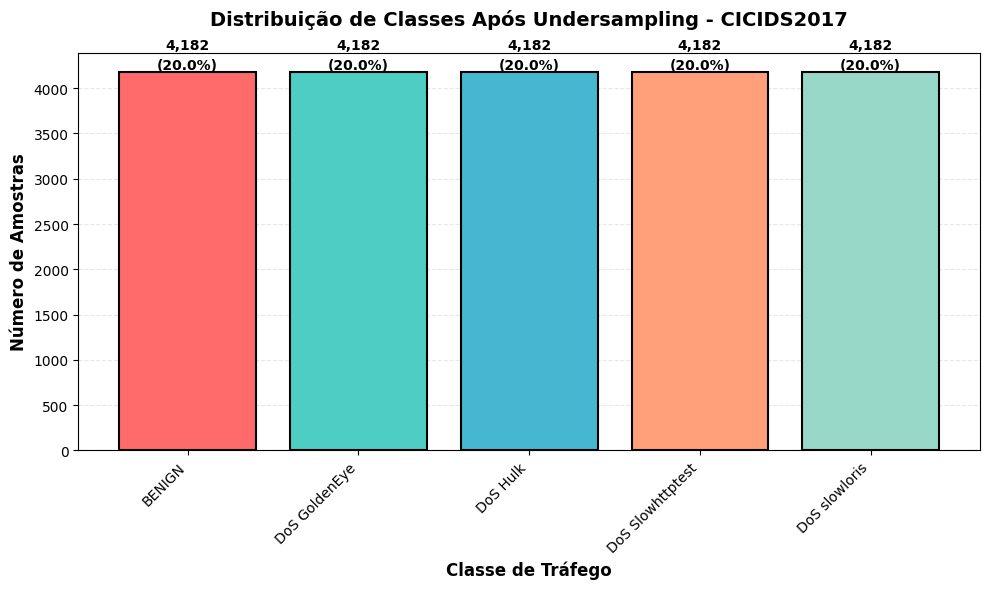

In [17]:
# Criar gráfico de balanceamento de classes APÓS UNDERSAMPLING
fig, ax = plt.subplots(figsize=(10, 6))

# Dados de contagem por label
label_data = df_train_bal[target].value_counts().sort_values(ascending=False)

# Cores personalizadas
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']

# Gráfico de barras
bars = ax.bar(
    range(len(label_data)),
    label_data.values,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

# Personalizações
ax.set_xlabel('Classe de Tráfego', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Amostras', fontsize=12, fontweight='bold')
ax.set_title(
    'Distribuição de Classes Após Undersampling - CICIDS2017',
    fontsize=14,
    fontweight='bold',
    pad=20
)

ax.set_xticks(range(len(label_data)))
ax.set_xticklabels(label_data.index, rotation=45, ha='right')

# Adicionar valores nas barras
for bar, value in zip(bars, label_data.values):
    height = bar.get_height()
    percentage = (value / label_data.sum()) * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        height,
        f'{value:,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        linespacing=1.5
    )

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# Ajustar layout
plt.tight_layout()

# Salvar imagem
plt.savefig('imagens/class_distribution_undersampling1.png', dpi=300)

# Exibir gráfico
plt.show()